In [94]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Setup CUDA device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cpu


In [93]:
g = torch.Generator().manual_seed(2147483647)

In [86]:
# Reading libraries

words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [87]:
# Mapping functions

chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [88]:
# Defining the constants

block_size = 3
hidden_layers = 300
dimensions = 20
vocab_size = len(itos)

In [89]:
# Building the dataset

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X).to(device)
    Y = torch.tensor(Y).to(device)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# Traning validation and testing split

Xtr, Ytr = build_dataset(words[:n1])
Xva, Yva = build_dataset(words[n1: n2])
Xte, Yte = build_dataset(words[n2:])

print(Xtr.shape, Ytr.shape)
print(Xte.shape, Yte.shape)
print(Xte.shape, Yte.shape)


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22866, 3]) torch.Size([22866])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.weight = self.weight.to(device)
        self.bias = torch.zeros(fan_out).to(device) if bias else None

    def __call__(self, x):
        # Removed torch.tensor(x) to preserve the computational graph
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    # Fixed: __init__ instead of __int__
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True  # Fixed: spelling

        # for backpropogation
        self.gamma = torch.ones(dim).to(device)
        self.beta = torch.zeros(dim).to(device)

        # buffers
        self.running_mean = torch.zeros(dim).to(device)
        self.running_var = torch.ones(dim).to(device)

    def __call__(self, x):
        # Removed torch.tensor(x)
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
            
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # updating the buffers
        if self.training:
            with torch.no_grad(): # Fixed: added parentheses
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
                
        return self.out # Fixed: unindented so it always returns
        
    def parameters(self):
        return [self.gamma, self.beta]
        

class Tanh:
    def __call__(self, x):
        # Removed torch.tensor(x)
        self.out = torch.tanh(x)
        return self.out # Fixed: actually return the output!
    
    def parameters(self):
        return []


# Constants (Assuming g and vocab_size are defined above this snippet)
n_embed = 10    
n_hidden = 100  

C = torch.randn((vocab_size, n_embed), generator=g).to(device)

# Note: You built BatchNorm1d but haven't added it to this list yet! 
# If you want to use it, interleave it between Linear and Tanh.
layers = [
     Linear(n_embed * block_size, n_hidden), Tanh(),
     Linear(n_hidden, n_hidden), Tanh(),
     Linear(n_hidden, n_hidden), Tanh(),
     Linear(n_hidden, n_hidden), Tanh(),
     Linear(n_hidden, n_hidden), Tanh(),
     Linear(n_hidden, vocab_size),
]
                
with torch.no_grad():
    # Less Confidence to the last layer
    layers[-1].weight *= 0.1
    # increasing the gain of the other layers
    for layer in layers:
        if isinstance(layer, Linear):
            # layer.weight *= 5/3
            layer.weight = 2

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True


46497


In [ ]:
# Traning loop with optimizations

epochs = 200000
batch_size = 32
lossi = []

for i in range(epochs):

    # Minbatch construction
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    # Ensure batch is on device
    Xb = Xb.to(device)
    Yb = Yb.to(device)

    # Forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # Learning rate updation
    lr = 0.1 if i < 100000 else 0.001
    for p in parameters:
        p.data += -lr * p.grad

    # Logging
    if i % 1000 == 0:
        print(f"{i:7d}/{epochs:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())


      0/ 200000 : 3.2986
   1000/ 200000 : 2.2701
   2000/ 200000 : 2.6713
   3000/ 200000 : 2.4694
   4000/ 200000 : 1.9505
   5000/ 200000 : 1.8710
   6000/ 200000 : 2.0387
   7000/ 200000 : 2.1992
   8000/ 200000 : 2.1586


KeyboardInterrupt: 

In [ ]:
# Visualiser

plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')

plt.legend(legends);
plt.title('Activation Distribution')

AttributeError: 'Tanh' object has no attribute 'out'

<Figure size 2000x400 with 0 Axes>

layer 1 (      Tanh): mean -0.000028, std 3.164695e-03
layer 3 (      Tanh): mean -0.000038, std 2.977459e-03
layer 5 (      Tanh): mean +0.000035, std 2.981170e-03
layer 7 (      Tanh): mean -0.000036, std 3.406582e-03
layer 9 (      Tanh): mean -0.000099, std 4.314033e-03


Text(0.5, 1.0, 'gradient distribution')

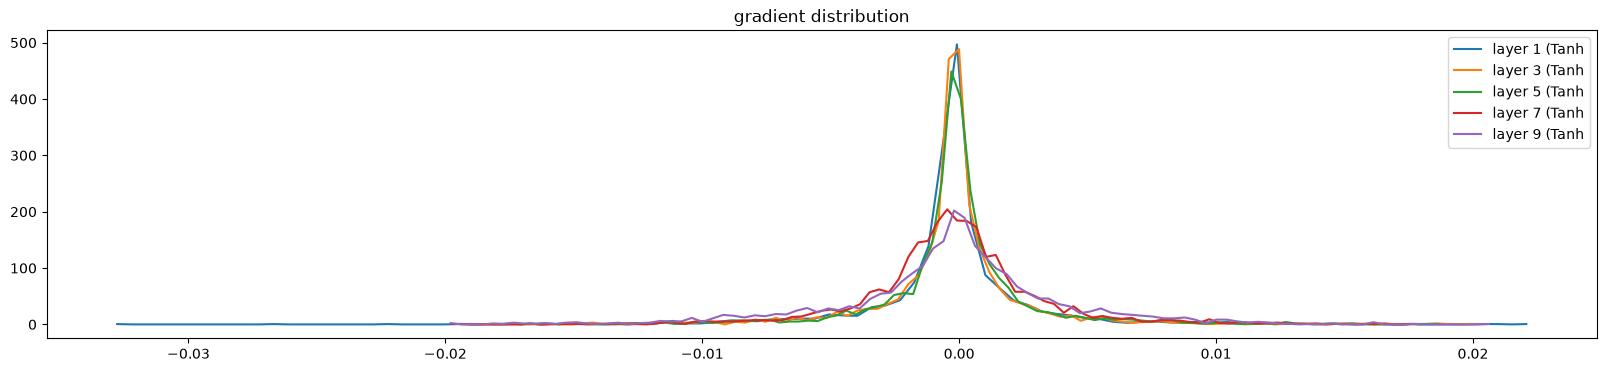

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000451 | std 1.300898e-02 | grad:data ratio 1.104886e-02
weight  (30, 100) | mean +0.000088 | std 8.112867e-03 | grad:data ratio 1.731347e-02
weight (100, 100) | mean +0.000057 | std 5.225200e-03 | grad:data ratio 1.883304e-02
weight (100, 100) | mean -0.000031 | std 5.113495e-03 | grad:data ratio 1.914787e-02
weight (100, 100) | mean +0.000036 | std 5.677186e-03 | grad:data ratio 2.165045e-02
weight (100, 100) | mean +0.000064 | std 6.581238e-03 | grad:data ratio 2.870671e-02
weight  (100, 27) | mean +0.000000 | std 2.347204e-02 | grad:data ratio 1.348513e-01


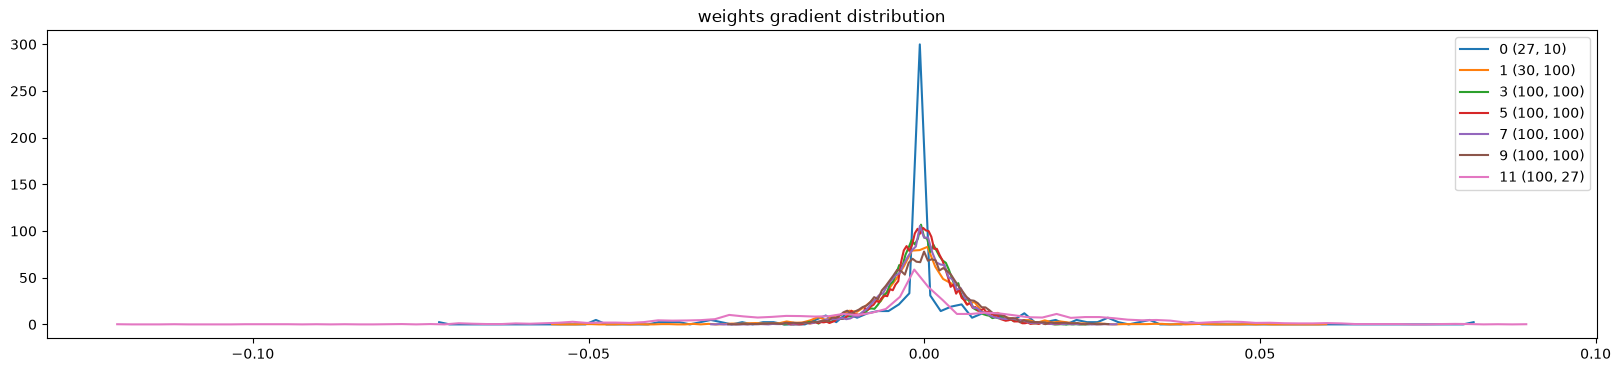

In [ ]:

#  visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

NameError: name 'ud' is not defined

<Figure size 2000x400 with 0 Axes>